In [3]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List, Optional
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet18, ResNet18_Weights
from dataclasses import dataclass
# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [6]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

Device: cpu


In [4]:
STL10_MEAN = (0.491, 0.482, 0.447)
STL10_STD  = (0.247, 0.244, 0.262)

def load_stl10(data_dir: str = DATA_DIR, extra_train_transforms=None):
    train_features = [transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),]
    if extra_train_transforms:
        train_features += extra_train_transforms
    
    tf_train = transforms.Compose(train_features)
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    ds_train_full = torchvision.datasets.STL10(root=data_dir, split = 'train', download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, split = 'test', download=True, transform=tf_test)

    return ds_train_full, ds_test

ds_train_full, ds_test = load_stl10()
class_names = ds_train_full.classes
print("Train full:", len(ds_train_full))
print("Test:", len(ds_test))
print("Classes:", class_names)

Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(800, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(800, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

c:\Users\ivasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


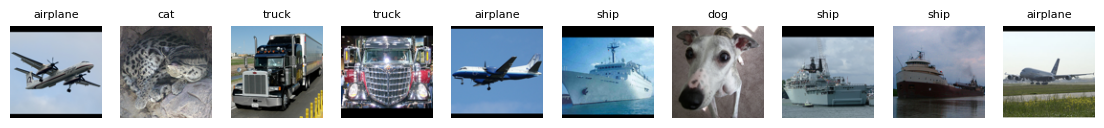

In [6]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [7]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1),   # 96x96 → 96x96
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 96x96 → 48x48

            nn.Conv2d(96, 64, kernel_size=3, padding=1),   # 48x48 → 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 48x48 → 24x24
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 24x24 → 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 24x24 → 12x12
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 4853322


In [8]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [9]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", filename: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    
    figures_dir = Path('artifacts/figures')
    plt.savefig(figures_dir / filename)
    plt.show()

In [10]:
criterion = nn.CrossEntropyLoss()
def run_experiment(exp_id: str, model: nn.Module, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}
res_cnn = run_experiment("CNN_simple", cnn, lr=1e-3, epochs=EPOCHS)


Experiment CNN_simple | lr=0.001 weight_decay=0.0 epochs=4
Trainable params: 4853322
Epoch 01/4 | train loss 2.1273, acc 0.239 | val loss 1.8341, acc 0.349 | 41.8s
Epoch 02/4 | train loss 1.6009, acc 0.423 | val loss 1.5845, acc 0.424 | 41.6s
Epoch 03/4 | train loss 1.4121, acc 0.483 | val loss 1.4935, acc 0.439 | 41.6s
Epoch 04/4 | train loss 1.2433, acc 0.552 | val loss 1.3236, acc 0.514 | 41.5s


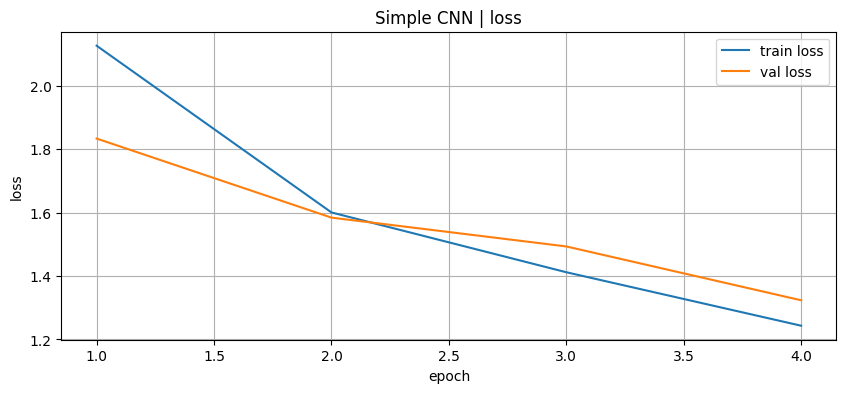

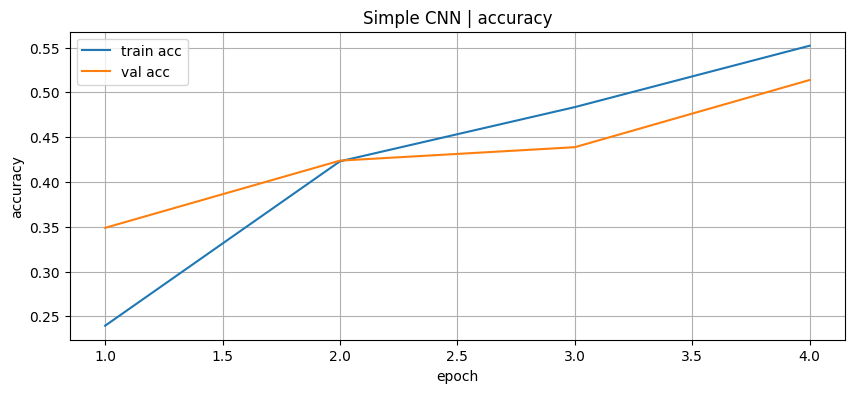


Experiment CNN_with_augmentations | lr=0.001 weight_decay=0.0 epochs=4
Trainable params: 4853322
Epoch 01/4 | train loss 1.9071, acc 0.285 | val loss 1.6049, acc 0.394 | 41.6s
Epoch 02/4 | train loss 1.4244, acc 0.473 | val loss 1.4795, acc 0.450 | 41.6s
Epoch 03/4 | train loss 1.1838, acc 0.568 | val loss 1.4345, acc 0.501 | 41.4s
Epoch 04/4 | train loss 0.9663, acc 0.648 | val loss 1.3695, acc 0.569 | 42.0s


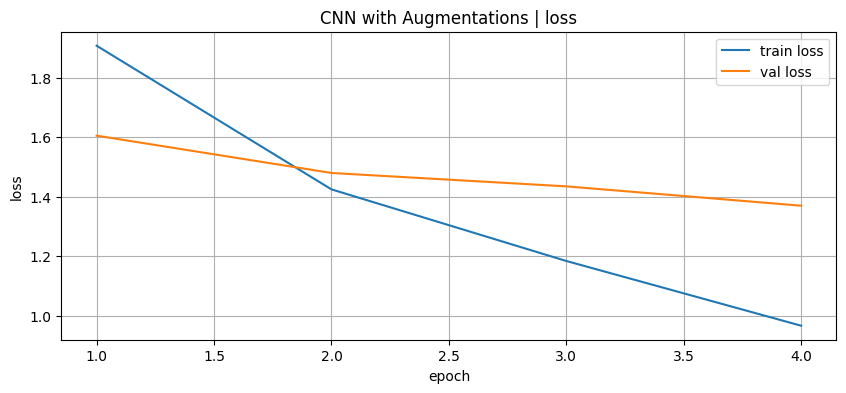

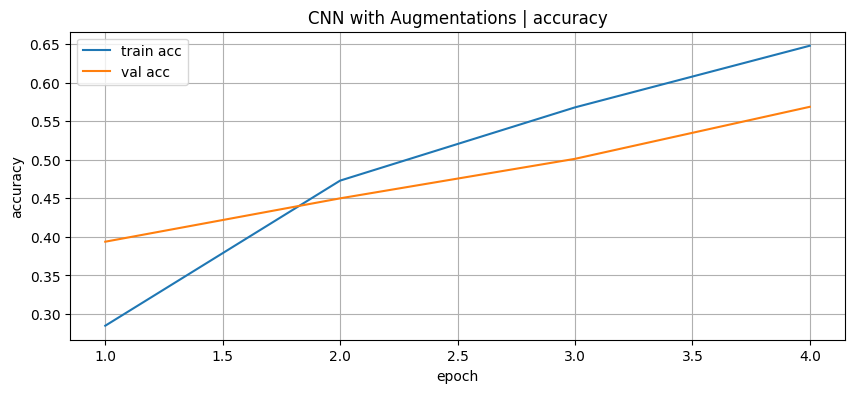

In [13]:
plot_history(res_cnn["history"], title="Simple CNN")

ds_train_full_aug, ds_test_aug = load_stl10(
    extra_train_transforms=[
        transforms.RandomCrop(96, padding=4),
        transforms.RandomInvert(p=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ]
)
train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(
    ds_train_full_aug, 
    ds_test_aug,
    fast_mode=FAST_MODE
)
cnn_aug = SimpleCNN(NUM_CLASSES).to(DEVICE)
res_aug_cnn = run_experiment(
    "CNN_with_augmentations",  # новое название эксперимента
    cnn_aug,              # новая модель
    lr=1e-3, 
    epochs=EPOCHS
)
plot_history(res_aug_cnn["history"], title="CNN with Augmentations")

In [16]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc_mlp = accuracy_on_loader(res_cnn["model"], test_loader)
test_acc_cnn = accuracy_on_loader(res_aug_cnn["model"], test_loader_aug)

print("Test acc (CNN):", round(test_acc_mlp, 4))
print("Test acc (CNN with aug):", round(test_acc_cnn, 4))

c:\Users\ivasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test acc (CNN): 0.5138
Test acc (CNN with aug): 0.5425


In [70]:
import pandas as pd
results_data = [
    {
        "experiment_id": "C1",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "(96,12) / ReLU / 0.0 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "4",
        "best_val_accuracy": 0.514,
        "test_accuracy": 0.5138,
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
        "experiment_id": "C2",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "(96,12) / ReLU / 0.0 / no batchnorm / augmentations: RandomCrop, RandomInvert, GaussianBlur",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "4",
        "best_val_accuracy": 0.514,
        "test_accuracy": 0.569,
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
        "experiment_id": "C3",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "224 / head only",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "3",
        "best_val_accuracy": 0.925,
        "test_accuracy": 0.927,
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
        "experiment_id": "C4",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "224 / head only/ fc + layer4",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "3",
        "best_val_accuracy": 0.943,
        "test_accuracy": 0.939,
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
    "experiment_id": "V1",
    "dataset": "KITTI",
    "seed": 42,
    "model_summary": "Faster R-CNN with ResNet50 backbone, pretrained on COCO",
    "optimizer": "SGD",
    "lr": 0.005,
    "epochs_trained": 10,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": 0.6250,
    "recall": 0.0658,
    "mean_iou": 0.6667,
    "notes": "score_threshold=0.3, iou_thr=0.3, person class only",
    },

    {
        "experiment_id": "V2",
        "dataset": "KITTI",
        "seed": 42,
        "model_summary": "Faster R-CNN with ResNet50 backbone, pretrained on COCO",
        "optimizer": "SGD",
        "lr": 0.005,
        "epochs_trained": 10,
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": "0.624",
        "recall": " 0.065",
        "mean_iou": "0.666",
        "notes": "score_threshold=0.7, iou_thr=0.7, person class only",
    }
    
]

df_results = pd.DataFrame(results_data)

csv_path = Path('./artifacts/runs.csv')
df_results.to_csv(csv_path, index=False, encoding='utf-8')

print(f"файл сохранён: {csv_path}")
print("\nПервые строки:")
df_results.head()

файл сохранён: artifacts\runs.csv

Первые строки:


,experiment_id,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,STL10,42,"(96,12) / ReLU / 0.0 / no batchnorm",Adam,0.001,4,0.514,0.5138,,,,
1,C2,STL10,42,"(96,12) / ReLU / 0.0 / no batchnorm / augmenta...",Adam,0.001,4,0.514,0.569,,,,
2,C3,STL10,42,224 / head only,Adam,0.001,3,0.925,0.927,,,,
3,C4,STL10,42,224 / head only/ fc + layer4,Adam,0.001,3,0.943,0.939,,,,
4,V1,KITTI,42,"Faster R-CNN with ResNet50 backbone, pretraine...",SGD,0.005,10,,,0.625,0.0658,0.6667,"score_threshold=0.3, iou_thr=0.3, person class..."


In [18]:
BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

In [19]:

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [22]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Для CIFAR-10 придётся изменить размер (ResNet обычно ожидает ~224x224).
# Чтобы было быстрее, можно выбрать размер 160 или 192. Оставим 224 как стандарт.
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_cifar10_tl(data_dir: str = DATA_DIR):
    # Важно: для train нужны аугментации, для val/test – детерминированные transforms.
    # Поэтому создаём ДВА варианта train-датасета с разными transforms и будем делить по одним и тем же индексам.
    ds_train_aug = torchvision.datasets.STL10(root=data_dir, split = 'train', download=True, transform=train_tf)
    ds_train_eval  = torchvision.datasets.STL10(root=data_dir, split = 'train', download=True, transform=eval_tf)
    ds_test = torchvision.datasets.STL10(root=data_dir, split = "test", download=True, transform=eval_tf)
    return ds_train_aug, ds_train_eval, ds_test

ds_train_aug, ds_train_eval, ds_test = load_cifar10_tl()
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

Train full: 5000
Test: 8000


In [23]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

c:\Users\ivasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [24]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ivasi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [36]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history1(hist: Dict[str, List[float]], title: str = "", filename: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()

    figures_dir = Path('artifacts/figures')
    plt.savefig(figures_dir / filename)
    
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()    
    plt.show()

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/3 | lr 1.00e-03 | train loss 1.0885, acc 0.719 | val loss 0.4892, acc 0.897 | 88.5s
Epoch 02/3 | lr 1.00e-03 | train loss 0.4053, acc 0.904 | val loss 0.3133, acc 0.925 | 87.5s
Epoch 03/3 | lr 1.00e-03 | train loss 0.2933, acc 0.929 | val loss 0.2683, acc 0.927 | 87.1s


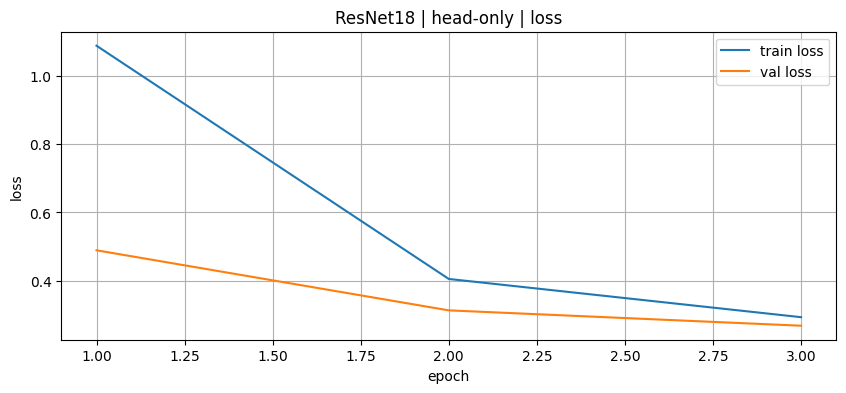

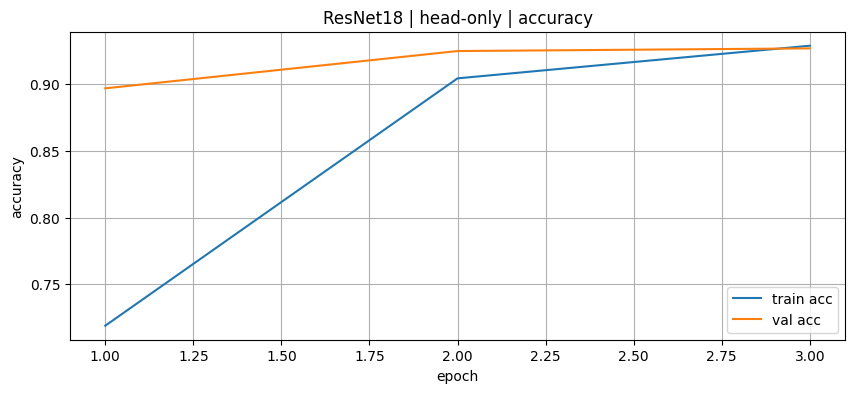

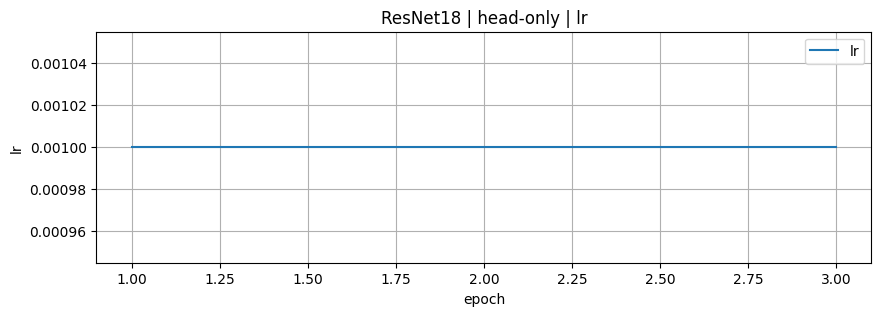

In [26]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/3 | lr 1.00e-04 | train loss 0.2282, acc 0.923 | val loss 0.1707, acc 0.940 | 106.3s
Epoch 02/3 | lr 1.00e-04 | train loss 0.0860, acc 0.971 | val loss 0.1480, acc 0.956 | 106.2s
Epoch 03/3 | lr 1.00e-04 | train loss 0.0536, acc 0.986 | val loss 0.1628, acc 0.943 | 106.6s


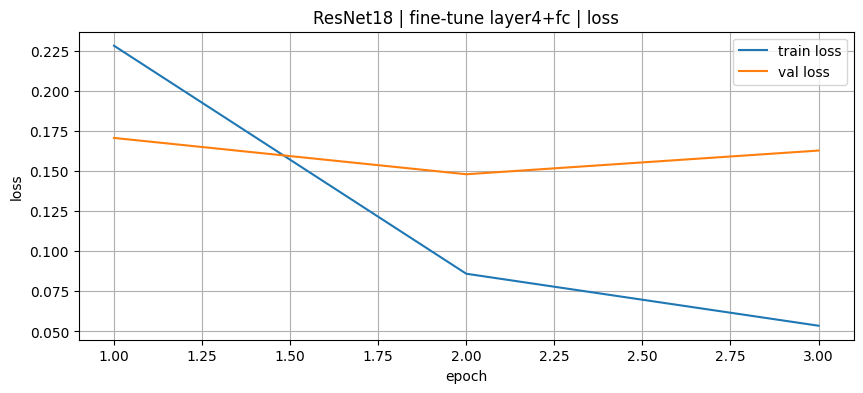

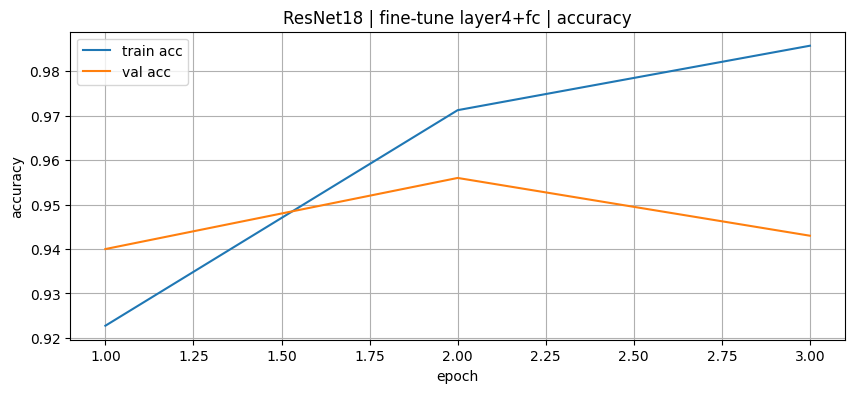

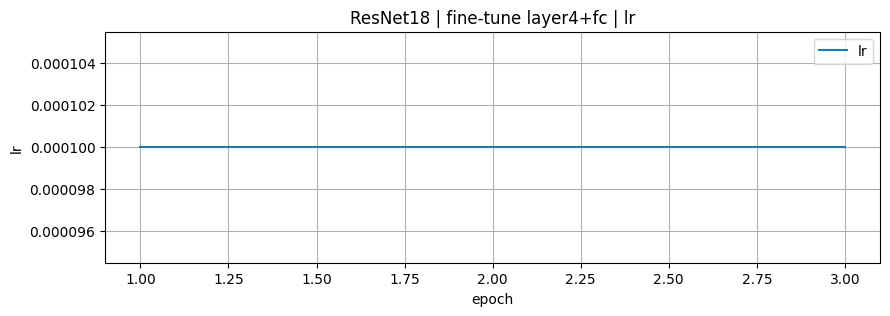

In [ ]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

In [29]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader)
print("Test acc:", round(test_acc, 4))

Test acc: 0.939


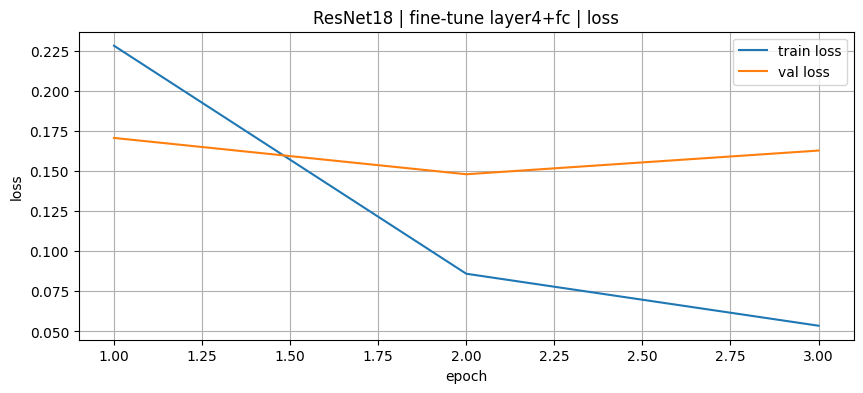

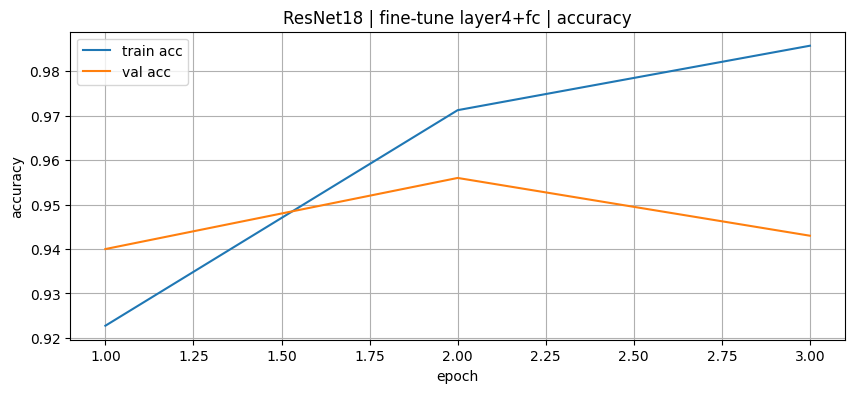

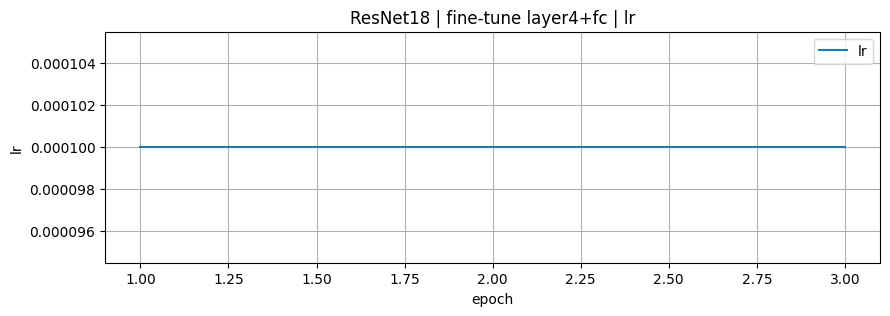

In [39]:
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc", filename= "classification_curves_best.png")

In [4]:
import json
from pathlib import Path

best_model_config = {
  "model_name": "ResNet18",
  "pretrained": True,
  "finetune_layers": "layer4+fc",
  "optimizer": "Adam",
  "lr": 0.001,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "dataset": "STL10",
  "seed": 42,
  "fast_mode": False,
  "epochs_trained": 3,
  "best_val_accuracy": 0.943,
  "best_val_loss": 0.215,
  "test_loss": 0.228,
  "test_accuracy": 0.939
}

config_path = Path('./artifacts/best_classifier_config.json')
config_path.parent.mkdir(parents=True, exist_ok=True)

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(best_model_config, f, indent=2, ensure_ascii=False)

print(json.dumps(best_model_config, indent=2, ensure_ascii=False))

{
  "model_name": "ResNet18",
  "pretrained": true,
  "finetune_layers": "layer4+fc",
  "optimizer": "Adam",
  "lr": 0.001,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "dataset": "STL10",
  "seed": 42,
  "fast_mode": false,
  "epochs_trained": 3,
  "best_val_accuracy": 0.943,
  "best_val_loss": 0.215,
  "test_loss": 0.228,
  "test_accuracy": 0.939
}


In [38]:
best_model_state = model_head.state_dict()
torch.save(best_model_state, 'artifacts/best_classifier.pt')

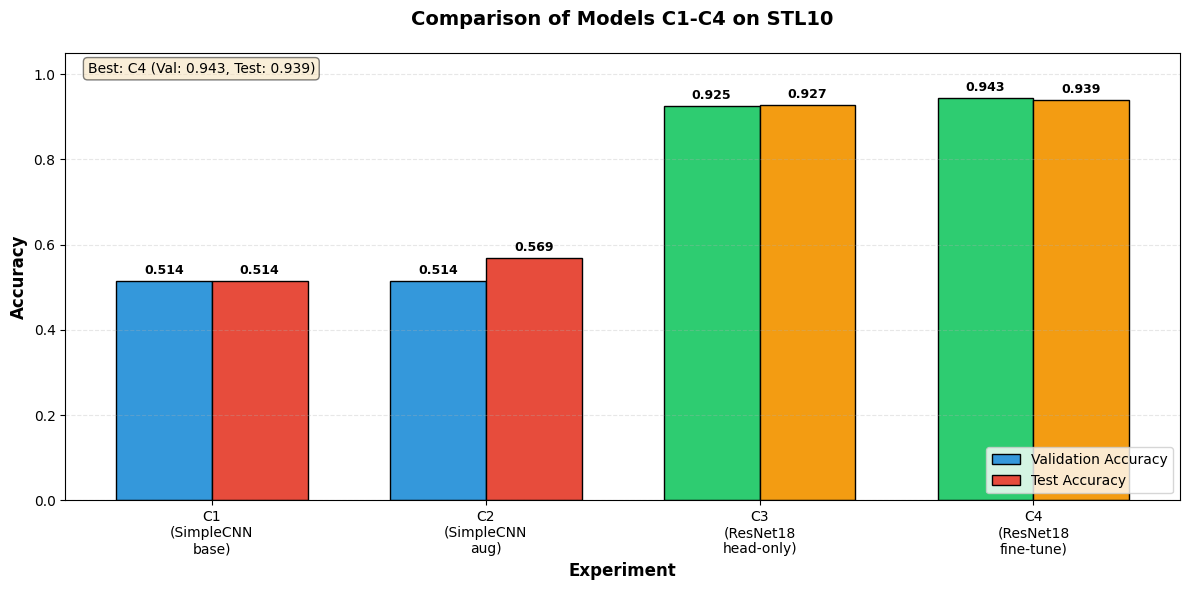

In [44]:

experiments = ['C1\n(SimpleCNN\nbase)', 'C2\n(SimpleCNN\naug)', 'C3\n(ResNet18\nhead-only)', 'C4\n(ResNet18\nfine-tune)']
val_accuracies = [0.514, 0.514, 0.925, 0.943]
test_accuracies = [0.514, 0.569, 0.927, 0.939]

colors_val = ['#3498db', '#3498db', '#2ecc71', '#2ecc71']
colors_test = ['#e74c3c', '#e74c3c', '#f39c12', '#f39c12']

x = np.arange(len(experiments))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, val_accuracies, width, label='Validation Accuracy', color=colors_val, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color=colors_test, edgecolor='black', linewidth=1)

ax.set_xlabel('Experiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Models C1-C4 on STL10', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

add_labels(bars1)
add_labels(bars2)

ax.text(0.02, 0.98, f'Best: C4 (Val: {val_accuracies[3]:.3f}, Test: {test_accuracies[3]:.3f})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

figures_dir = Path('./artifacts/figures')

save_path = figures_dir / 'classification_compare.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image

def denorm(tensor):
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return tensor * std + mean

ds_sample = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=None)
original_img, label = ds_sample[0]

transform_c2 = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.2, 1.0)),
    transforms.RandomCrop(96, padding=4),
    transforms.RandomInvert(p=1.0),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('STL10 Augmentation Preview (Part A: C2)', fontsize=14, fontweight='bold')

for i in range(4):
    aug_img = transform_c2(original_img)
    aug_img = denorm(aug_img).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i+1}', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()

figures_dir = Path('artifacts/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'augmentations_preview.png', dpi=150, bbox_inches='tight')

plt.show()

NameError: name 'STL10_MEAN' is not defined

In [8]:
# 2) Конфигурация
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.7         # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=4, score_thr=0.7, iou_thr=0.5, model_name='fasterrcnn_mobilenet_v3_large_fpn')

In [9]:
# 3) Данные: KITTI (download/unzip при необходимости)

KITTI_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/kitti.zip"

def ensure_kitti(root: str) -> str:
    '''
    Гарантируем наличие папки root/KITTI.
    Возвращаем путь к KITTI.
    '''
    kitti_root = os.path.join(root, "KITTI")
    if os.path.isdir(kitti_root):
        return kitti_root

    os.makedirs(root, exist_ok=True)

    # Скачивание через torchvision утилиту (если доступно)
    try:
        import torchvision
        from torchvision.datasets.utils import download_and_extract_archive
        print("Downloading KITTI to:", root)
        download_and_extract_archive(KITTI_URL, download_root=root, filename="KITTI.zip", remove_finished=False)
        if not os.path.isdir(kitti_root):
            raise FileNotFoundError("После распаковки не найдено KITTI/. Проверьте содержимое папки data_dir.")
        return kitti_root
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {KITTI_URL}")
        print(f"2) распакуйте так, чтобы было: {kitti_root}/images и {kitti_root}/labels")
        raise

kitti_root = ensure_kitti(cfg.data_dir)
kitti_root

'./data\\KITTI'

In [10]:
import torch.utils.data

class KITTIDetDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "images")
        self.label_dir = os.path.join(root, "labels")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".jpg") or f.lower().endswith(".png")])
        
        # KITTI labels в формате .txt
        self.labels = [f.replace(".jpg", ".txt").replace(".png", ".txt") for f in self.imgs]

        if len(self.imgs) == 0:
            raise RuntimeError("Похоже, структура KITTI повреждена или не распакована полностью.")

        # преобразуем PIL -> torch.Tensor [0..1]
        try:
            from torchvision.transforms import ToTensor
            self.to_tensor = ToTensor()
        except Exception as e:
            raise RuntimeError("Нужен torchvision для ToTensor().") from e

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        label_path = os.path.join(self.label_dir, self.labels[idx])

        img = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        
        # Читаем KITTI формат: class x_center y_center width height
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_center = float(parts[1])
                        y_center = float(parts[2])
                        width = float(parts[3])
                        height = float(parts[4])
                        
                        # Конвертируем из normalized coordinates в абсолютные
                        w, h = img.size
                        xmin = (x_center - width/2) * w
                        ymin = (y_center - height/2) * h
                        xmax = (x_center + width/2) * w
                        ymax = (y_center + height/2) * h
                        
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(class_id + 1)  # +1 потому что 0 = background

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        image_id = torch.tensor([idx], dtype=torch.int64)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        img_t = self.to_tensor(img)
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = KITTIDetDataset(kitti_root)
len(dataset), dataset[0][0].shape, dataset[0][1].keys()

(5985,
 torch.Size([3, 375, 1242]),
 dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd']))

In [12]:
def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        fasterrcnn_mobilenet_v3_large_fpn,
        retinanet_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights,
        FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        RetinaNet_ResNet50_FPN_V2_Weights,
    )

    name = name.strip()

    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "retinanet_resnet50_fpn_v2":
        weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
        model = retinanet_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {name}")

    categories = weights.meta.get("categories", None)
    person_label = None
    if categories and "person" in categories:
        person_label = categories.index("person")  # у COCO обычно 1

    model.eval()
    return model, weights, categories, person_label

model, weights, categories, person_label = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)
print("person_label:", person_label)

model: fasterrcnn_mobilenet_v3_large_fpn
person_label: 1


NameError: name 'figures_dir' is not defined

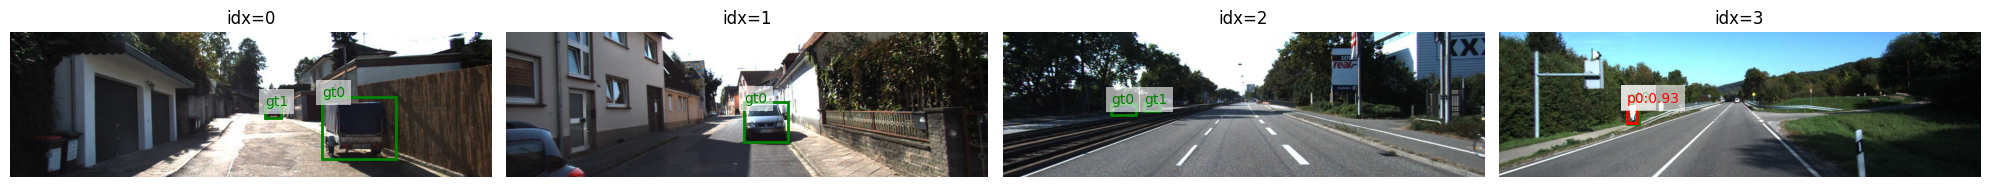

In [13]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

# Покажем несколько примеров
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, cfg.score_thr, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.savefig(figures_dir / 'detection_examples.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'predict_one' is not defined

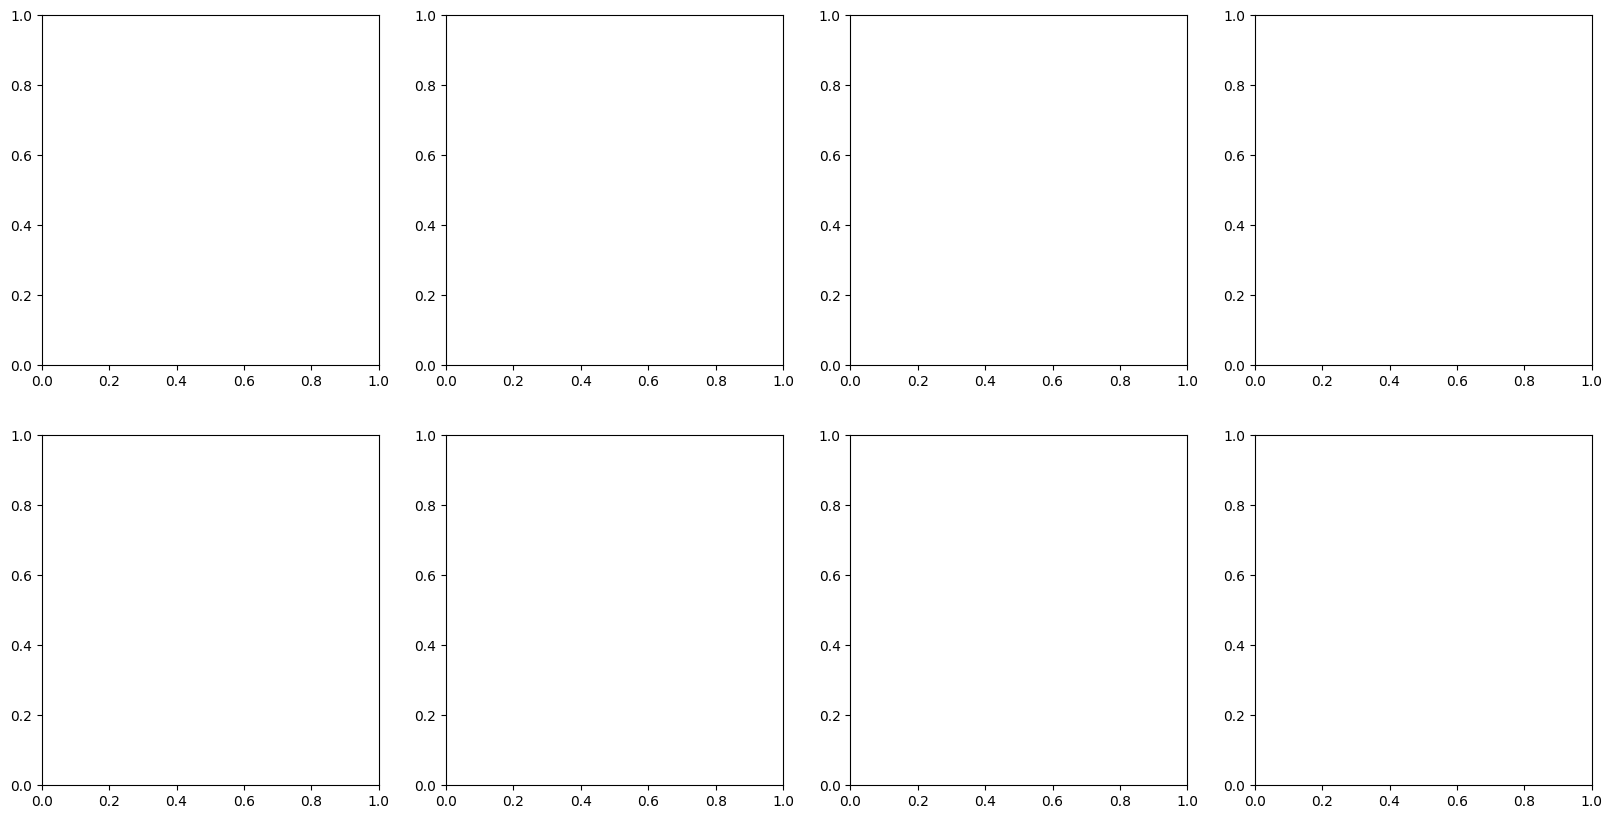

In [11]:
from typing import Dict, List, Optional

# Покажем сравнение V1 (thr=0.3) и V2 (thr=0.7)
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(2, n, figsize=(5*n, 10))

if n == 1:
    axes = axes.reshape(2, 1)

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    
    # V1: threshold = 0.3
    pred_v1 = filter_preds(pred, score_thr=0.3, person_label=person_label)
    
    # V2: threshold = 0.7
    pred_v2 = filter_preds(pred, score_thr=0.7, person_label=person_label)
    
    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    
    # Верхний ряд: V1 (thr=0.3)
    ax = axes[0, i]
    ax.imshow(img_np)
    ax.set_title(f"V1 (thr=0.3) idx={i}")
    ax.axis("off")
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_v1["boxes"], color="r", linewidth=2, text=lambda j: f"{pred_v1['scores'][j]:.2f}")
    
    # Нижний ряд: V2 (thr=0.7)
    ax = axes[1, i]
    ax.imshow(img_np)
    ax.set_title(f"V2 (thr=0.7) idx={i}")
    ax.axis("off")
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_v2["boxes"], color="r", linewidth=2, text=lambda j: f"{pred_v2['scores'][j]:.2f}")

plt.tight_layout()
plt.show()

In [67]:

def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, cfg.score_thr, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = evaluate_subset(eval_indices)
metrics

{'TP': 5.0,
 'FP': 3.0,
 'FN': 71.0,
 'precision@IoU': 0.624999999921875,
 'recall@IoU': 0.06578947368334487,
 'F1@IoU': 0.11904761887244898,
 'mean_IoU_matched': 0.6666973034540812}

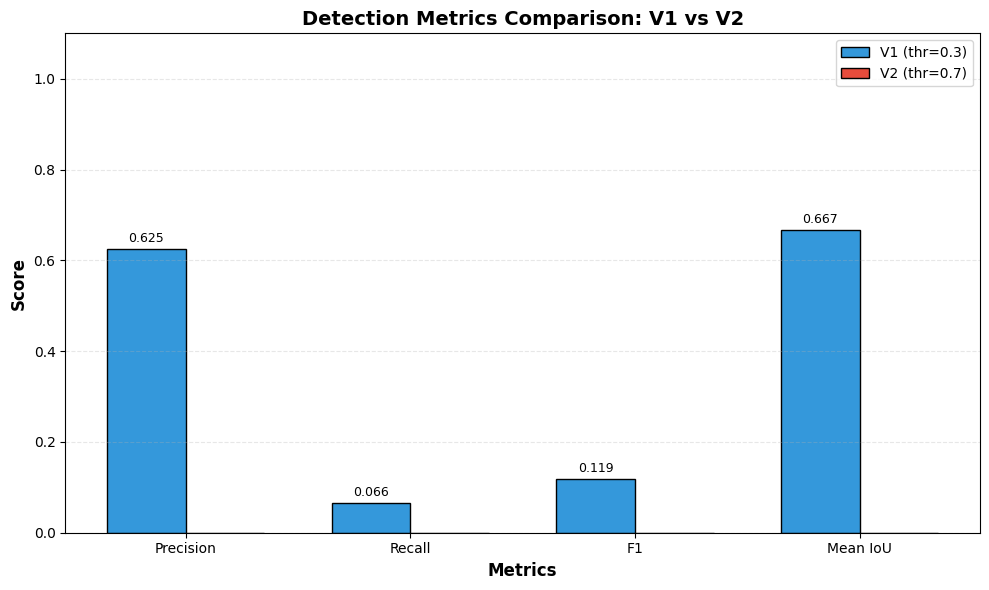

In [ ]:

metrics_v1 = {'precision': 0.6250, 'recall': 0.0658, 'f1': 0.1190, 'mean_iou': 0.6667}
metrics_v2 = {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'mean_iou': 0.0}

metrics_names = ['Precision', 'Recall', 'F1', 'Mean IoU']
v1_values = [metrics_v1['precision'], metrics_v1['recall'], metrics_v1['f1'], metrics_v1['mean_iou']]
v2_values = [metrics_v2['precision'], metrics_v2['recall'], metrics_v2['f1'], metrics_v2['mean_iou']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, v1_values, width, label='V1 (thr=0.3)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, v2_values, width, label='V2 (thr=0.7)', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Detection Metrics Comparison: V1 vs V2', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

plt.savefig(figures_dir / 'detection_metrics.png', dpi=150, bbox_inches='tight')


plt.tight_layout()
plt.show()